## CHURN RATE MODEL FOR AUREAMIND
Churn rate, also known as the rate of attrition or customer churn, is the rate at which customers stop doing business with an entity. It is most commonly expressed as the percentage of service subscribers who discontinue their subscriptions within a given time period. It is also the rate at which employees leave their jobs within a certain period.

In this Notebook, the abbandontment app rate will be explored.
Even thoght it is synthetic data, the Churn Model will be ready to just adjust the parameters when real data is delivered.

### Benefits of Using the Churn Rate
The advantage of calculating a churn rate for AureaMind is that it provides clarity on how well the app is retaining customers, which is a reflection on the quality of the service the app is providing, as well as its usefulness.

In case churn rate is increasing from period to period, this can show that fundamental components of how to improve, what is failing or even the user's history may be an indicator of future abandontment. This all can indicate a few potential problems:

* Faulty service(s)
* Poor customer service
* Cost is higher than utility to customers.
* Some users are more suitable to stay and succed in the app.

The churn rate helps to understand why customers leave and what needs fixing. 

Acquiring new customers costs more than keeping current ones, so reducing churn rate saves money.

In [1]:
import pandas as pd
import numpy as np
import os
os.chdir('C:/Users/vorte/Documents/AureaMind/data/raw')

In [5]:
# uploading DFs

users = pd.read_csv('users.csv')
assessments = pd.read_csv('assessments.csv')
sessions = pd.read_csv('sessions.csv')
engagement = pd.read_csv('engagement.csv')
content_usage = pd.read_csv('content_usage.csv') 
outcomes= pd.read_csv('engagement.csv')

In [7]:
# Choosing the relevant Dataframes for Churn model
# Exploratory Data Analyst for each DF can be found at "EDA AureaMind.ipynb"

users.head()

,user_id,age,country,education_level,employment_status,relationship_status,has_children,baseline_stress,baseline_anxiety,baseline_depression,signup_date,program_type,dropout,dropout_date
0,1,30,Colombia,High School,Student,Single,False,5.0,5.0,6.0,2025-10-20,Therapy,True,2025-12-31
1,2,32,Colombia,Bachelor,Freelancer,Married,False,3.0,7.0,4.0,2025-10-07,Therapy,False,2025-12-31
2,3,40,Argentina,PhD,Employed,In Relationship,True,4.0,5.0,4.0,2025-10-21,Therapy,False,2025-12-31
3,4,47,Brazil,Bachelor,Freelancer,Single,True,2.0,6.0,5.0,2025-09-19,Coaching,False,2025-12-31
4,5,45,Canada,Bachelor,Freelancer,Married,True,7.0,6.0,6.0,2025-07-06,Basic,False,2025-12-31


### NOTE:
Since Users.csv is already giving a user_id and signup_date columns, a dropout boolean field and even the dropout_date column, this DF is enough to calculate de churn rate.

Chrun Model does not provide clarity on the types of customers leaving, this variables may depend of other DF or fields like "baseline_anxiety", a clustering will be studied later and maybe a churn model for each group to identify the perfect user.

#### FORMULA:  
(total_subscribers_lost / total_subscribers_acquired) * 100  = abandonment %        =
(len(users[users['dropout'] == True]) / len(users)) * 100    = abandonment %        =
users['dropout'].mean() * 100    = abandonment % 

When the 'dropout' field is boolean, it will  only count the "True" users however .mean() will calculate de division of "true" values/ all the observations. thats why it works.

In [10]:
# Calculating rate
abandontment_rate = users['dropout'].mean() * 100
print(f" There is a {abandontment_rate}% rate of abbandonment") 

 There is a 30.5% rate of abbandonment


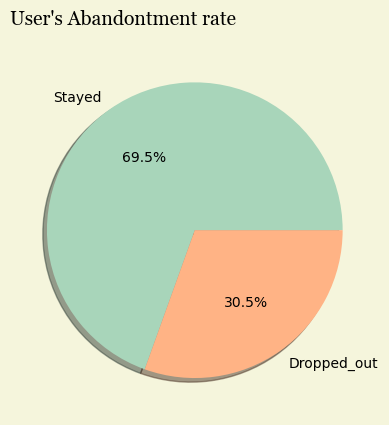

In [12]:
# First graphic: Visual observation of abbandonment rate
# Question answered: ¿How many users drop the app vs how many stay?

import matplotlib.pyplot as plt

counts = users['dropout'].value_counts()

plt.figure(facecolor = 'beige')
plt.gca().set_facecolor('beige')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.pie(counts, labels = ['Stayed','Dropped_out'], colors = ['#A8D5BA','#FFB385'], autopct = '%1.1f%%', shadow = True)
plt.title("User's Abandontment rate", fontsize = 14, fontname ='Georgia', pad = 15, loc = 'left' )

plt.savefig("User's Abandontment rate.png", dpi=300, bbox_inches = 'tight')
plt.show()

In [14]:
# Defining the DF of droped out users for future usability:
dropedout_df = users[users['dropout'] == True]
dropedout_df.head()

,user_id,age,country,education_level,employment_status,relationship_status,has_children,baseline_stress,baseline_anxiety,baseline_depression,signup_date,program_type,dropout,dropout_date
0,1,30,Colombia,High School,Student,Single,False,5.0,5.0,6.0,2025-10-20,Therapy,True,2025-12-31
8,9,35,Canada,PhD,Unemployed,Single,True,5.0,9.0,3.0,2025-12-20,Therapy,True,2025-12-31
12,13,26,Chile,High School,Student,In Relationship,False,6.0,5.0,4.0,2025-11-07,Holistic,True,2025-12-31
15,16,33,Chile,PhD,Freelancer,Single,False,2.0,6.0,4.0,2025-07-07,Basic,True,2025-11-16
16,17,36,USA,Bachelor,Student,In Relationship,False,3.0,8.0,8.0,2025-12-12,Holistic,True,2025-12-31


C:\Users\vorte\AppData\Local\Temp\ipykernel_2588\2045036064.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dropedout_df['dropout_date'] = pd.to_datetime(dropedout_df['dropout_date'])
C:\Users\vorte\AppData\Local\Temp\ipykernel_2588\2045036064.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_dropouts = dropedout_df.set_index('dropout_date').resample('M').size()


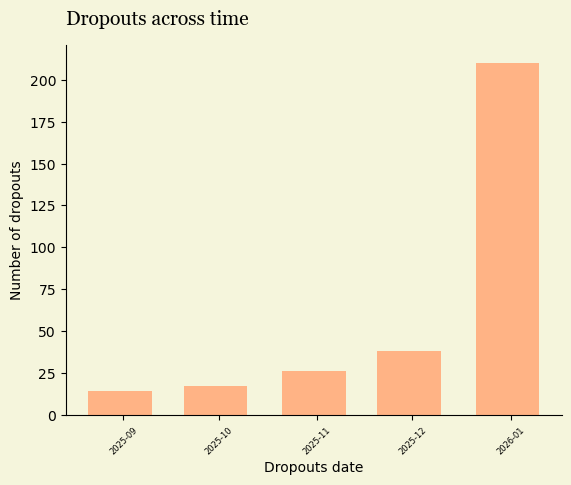

In [54]:
# grafic 2: Temporary Distribution of abbandonment
# Question answered: ¿When does abbandontment occurs?

# Just in case, converting to_datetime()
dropedout_df['dropout_date'] = pd.to_datetime(dropedout_df['dropout_date'])
# GRoup by month:
monthly_dropouts = dropedout_df.set_index('dropout_date').resample('M').size()


plt.figure(facecolor = 'beige')
plt.gca().set_facecolor('beige')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.bar(monthly_dropouts.index, monthly_dropouts.values, color = '#FFB385', width=20)
plt.title('Dropouts across time', fontsize = 14, loc = 'left', pad = 15, fontname = 'Georgia')
plt.xlabel("Dropouts date")
plt.ylabel("Number of dropouts")
plt.xticks(rotation = 45, fontsize = 6)

plt.savefig('Dropouts across time',dpi =300, bbox_inches ='tight')
plt.show()

In [18]:
# Corroborando el pico tan alto observado en el grafico
dropedout_df[dropedout_df['dropout_date']== '2025-12-31']

,user_id,age,country,education_level,employment_status,relationship_status,has_children,baseline_stress,baseline_anxiety,baseline_depression,signup_date,program_type,dropout,dropout_date
0,1,30,Colombia,High School,Student,Single,False,5.0,5.0,6.0,2025-10-20,Therapy,True,2025-12-31
8,9,35,Canada,PhD,Unemployed,Single,True,5.0,9.0,3.0,2025-12-20,Therapy,True,2025-12-31
12,13,26,Chile,High School,Student,In Relationship,False,6.0,5.0,4.0,2025-11-07,Holistic,True,2025-12-31
16,17,36,USA,Bachelor,Student,In Relationship,False,3.0,8.0,8.0,2025-12-12,Holistic,True,2025-12-31
18,19,37,Brazil,PhD,Student,Single,False,4.0,3.0,4.0,2025-12-27,Therapy,True,2025-12-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
982,983,23,Colombia,High School,Employed,Married,True,6.0,4.0,3.0,2025-10-15,Holistic,True,2025-12-31
986,987,26,USA,PhD,Employed,Married,False,8.0,4.0,3.0,2025-12-26,Coaching,True,2025-12-31
987,988,23,Colombia,High School,Student,Married,False,6.0,6.0,8.0,2025-09-12,Therapy,True,2025-12-31
992,993,50,Brazil,High School,Freelancer,Single,True,4.0,6.0,6.0,2025-10-23,Basic,True,2025-12-31


### Note:
Como se obserba un pico muy alto en los dropouts en la fecha que coincide con el FINISH_DAY, se cree que es un error al generar los datos sinteticos. por lo que la funcion generate_users() sera re considerada y con ello todo el experimento. 

C:\Users\vorte\AppData\Local\Temp\ipykernel_2588\2915694849.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_signups = users.set_index('signup_date').resample('M').size()


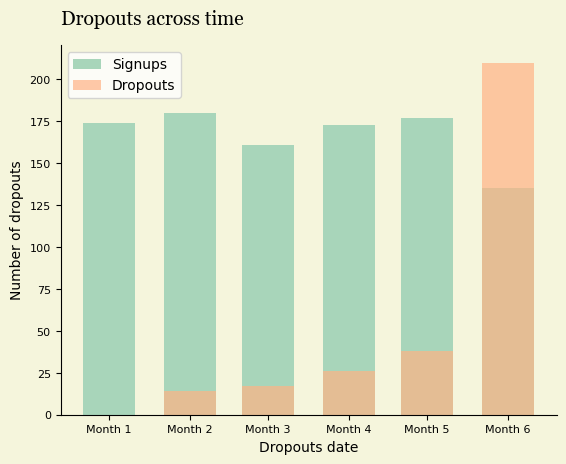

In [52]:
# Graphic 3: A bar plot that compares the singup_date with dropout_date across time:

# Creating the values:
users['signup_date'] = pd.to_datetime(users['signup_date'])
# GRoup by month:
monthly_signups = users.set_index('signup_date').resample('M').size()
ticks = ['Month 1','Month 2','Month 3','Month 4', 'Month 5','Month 6',]

# ploting:
plt.figure(facecolor = 'beige')
plt.gca().set_facecolor('beige')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.bar(monthly_signups.index, monthly_signups.values, color = '#A8D5BA', width=20, label = 'Signups')
plt.bar(monthly_dropouts.index, monthly_dropouts.values,  color = '#FFB385', width=20, label = 'Dropouts', alpha = 0.7)
plt.title('Dropouts across time', fontsize = 14, loc = 'left', pad = 15, fontname = 'Georgia')
plt.xlabel("Dropouts date")
plt.ylabel("Number of dropouts")
plt.xticks(monthly_signups.index, ticks, fontsize = 8)
plt.yticks(fontsize = 8)
plt.legend()

plt.savefig("Signs and Drops across time",dpi = 300, bbox_inches = 'tight')
plt.show()

## Logistic Regresion "Churn Model" (Binary Classification)
This model is trained to estimate the probability that a user will drop out of the program using baseline demographic and psychological features available at signup.

The output is a probability between 0 and 1 representing individual dropout risk.
A classification label (0 = No Dropout, 1 = Dropout) can be assigned using a selected decision threshold.

Because this model relies only on initial user information, it allows early identification of high-risk profiles before behavioral engagement data is incorporated.

In [22]:
# Defining target variable:
Y = users['dropout']
X = users.drop(columns = ['user_id','dropout','signup_date','dropout_date'])

In [24]:
X.head()

,age,country,education_level,employment_status,relationship_status,has_children,baseline_stress,baseline_anxiety,baseline_depression,program_type
0,30,Colombia,High School,Student,Single,False,5.0,5.0,6.0,Therapy
1,32,Colombia,Bachelor,Freelancer,Married,False,3.0,7.0,4.0,Therapy
2,40,Argentina,PhD,Employed,In Relationship,True,4.0,5.0,4.0,Therapy
3,47,Brazil,Bachelor,Freelancer,Single,True,2.0,6.0,5.0,Coaching
4,45,Canada,Bachelor,Freelancer,Married,True,7.0,6.0,6.0,Basic


In [26]:
# Encoding categorical variables into numerical for the model to work
X = pd.get_dummies(X,drop_first = True)
X.head()

,age,has_children,baseline_stress,baseline_anxiety,baseline_depression,country_Brazil,country_Canada,country_Chile,country_Colombia,country_Mexico,...,education_level_Master,education_level_PhD,employment_status_Freelancer,employment_status_Student,employment_status_Unemployed,relationship_status_Married,relationship_status_Single,program_type_Coaching,program_type_Holistic,program_type_Therapy
0,30,False,5.0,5.0,6.0,False,False,False,True,False,...,False,False,False,True,False,False,True,False,False,True
1,32,False,3.0,7.0,4.0,False,False,False,True,False,...,False,False,True,False,False,True,False,False,False,True
2,40,True,4.0,5.0,4.0,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
3,47,True,2.0,6.0,5.0,True,False,False,False,False,...,False,False,True,False,False,False,True,True,False,False
4,45,True,7.0,6.0,6.0,False,True,False,False,False,...,False,False,True,False,False,True,False,False,False,False


In [28]:
# Separating variables between Train y Test
from sklearn.model_selection import train_test_split

X_train,X_test,y_train, y_test = train_test_split(X,Y,random_state = 42,stratify = Y)
print(f"There are {len(X_train)} training observations and {len(X_test)} test observations")

There are 750 training observations and 250 test observations


In [30]:
#creating the Logistic Regression Model:
from sklearn.linear_model import LogisticRegression as LR

model = LR(max_iter = 1000, class_weight='balanced')
model.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [32]:
# Evaluating the model:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
y_pred

array([ True, False, False, False, False, False,  True, False, False,
        True, False,  True,  True,  True, False,  True, False, False,
       False, False, False, False, False, False,  True, False, False,
       False, False, False,  True,  True,  True, False, False,  True,
       False,  True, False, False, False, False, False, False, False,
       False, False,  True,  True, False,  True,  True,  True,  True,
        True, False, False,  True, False,  True, False, False,  True,
        True, False, False, False, False, False,  True, False,  True,
        True,  True,  True,  True, False, False, False, False, False,
        True,  True, False,  True, False,  True,  True, False, False,
        True,  True,  True, False,  True, False, False, False,  True,
        True, False,  True, False, False,  True, False,  True, False,
        True,  True,  True, False,  True,  True, False, False, False,
       False,  True,  True, False,  True, False, False, False, False,
        True, False,

As we can fast-see, the arrauy contains mostly False results and a few True results.. meaning very few (True) dropouts are predicted

In [36]:
y_prob

array([0.50139092, 0.40095708, 0.45906821, 0.44783558, 0.44044875,
       0.42498542, 0.55257988, 0.27536561, 0.46482508, 0.50341582,
       0.48314975, 0.57865785, 0.52300697, 0.61167538, 0.41695559,
       0.53427157, 0.33678948, 0.49502732, 0.37227731, 0.3954676 ,
       0.49174561, 0.46167217, 0.34699265, 0.33125464, 0.50324606,
       0.40192198, 0.42009959, 0.46526098, 0.39968524, 0.40245896,
       0.52811861, 0.51049596, 0.52307671, 0.41893969, 0.42330453,
       0.52182847, 0.28984823, 0.72550812, 0.47309837, 0.33632763,
       0.34170442, 0.39939244, 0.38753533, 0.44576191, 0.24463367,
       0.42315798, 0.30374896, 0.57823085, 0.55683607, 0.42547266,
       0.71209276, 0.61760959, 0.64596516, 0.5219682 , 0.54321399,
       0.44016746, 0.49803277, 0.64543707, 0.46556419, 0.56463535,
       0.42951343, 0.34170126, 0.70190235, 0.67988961, 0.35823913,
       0.4708757 , 0.3653187 , 0.38039411, 0.30719837, 0.54238162,
       0.39898051, 0.63400792, 0.65214082, 0.55314078, 0.54297

By the other hand y_prob shows the probability of dropping the app per user, where higher scores show higher probability and closed to 0 scores show small probabilitu of dropout per observation.

In [39]:
# Evaluation model
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       False       0.70      0.58      0.63       174
        True       0.30      0.42      0.35        76

    accuracy                           0.53       250
   macro avg       0.50      0.50      0.49       250
weighted avg       0.58      0.53      0.55       250



In [268]:
roc_auc = roc_auc_score(y_test,y_prob)
print("ROC-AUC:",roc_auc)

ROC-AUC: 0.5078644888082275


### Evaluation:
Model seems to be pretty bad as it is right now, the True Recall score is bigger than the original data(0.42), when we know about 30% of users droped out.
Appart from that, the Roc-AUC score is 50, which meand is almost random, like if variables wouldn't be related to the Y variable.

### It is important to mention:
Synthetic Data can be like this, Models like Churn Model ussually predict from behavioral variables and in the case of synthetic data it is all made with numpy.random.. ;Meaning a reason for the random predictions.

This outcome is consistent with the synthetic data generation process, where dropout was simulated independently of user characteristics. Therefore, the model correctly identifies the absence of statistical signal.

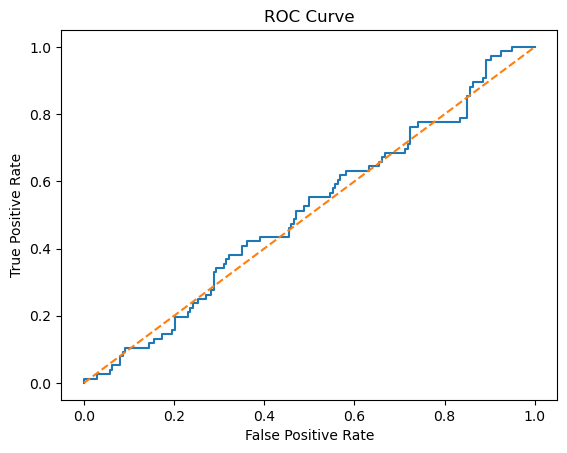

In [256]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

## Future Steps for Churn Model
### PipeLines, steps to follow:
1. Separate again X and Y from the original DataFrame, for future standarizations and encoding
2. Separating categorical and numeric columns for standarization, this would improve the model in most of the cases when non synthetic data arrives.4
3. import transformers and encoders: from sklearn.preprocessing import OneHotEncoder, StandardScaler, from sklearn.compose import ColumnTransformer.
4. preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), numeric_cols),('cat', OneHotEncoder(drop='first'), categorical_cols)])
5. Create the pipeline: from sklearn.pipeline import Pipeline, from sklearn.linear_model import LogisticRegression
6. pipeline = Pipeline(steps=[('preprocessing', preprocessor),('model', LogisticRegression(max_iter=1000))])
7. Divide the observations in train and split from sklearn.model_selection import train_test_split
8. train the model frompipeline: pipeline.fit(X_train, y_train)
9. Create predictions and evluate the model: from sklearn.metrics import classification_report, roc_auc_score
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))

In [57]:
# Separating categorical and numeric columns for standarization, this would improve the model in most of the cases when non synthetic data arrives.

y = users['dropout']
X = users.drop(columns = ['user_id','dropout','signup_date','dropout_date'])
X_categorical = X.select_dtypes(exclude = ['number']).columns
X_numerical = X.select_dtypes(include = ['number']).columns

# Encoders:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Creating a preprocessor
preprocessor = ColumnTransformer(transformers = [('num', StandardScaler(), X_numerical),('cat',OneHotEncoder(drop = 'first'), X_categorical)])

In [61]:
# Create the pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
pipeline = Pipeline(steps=[('preprocessing', preprocessor),('model', LogisticRegression(max_iter=1000))])

In [67]:
# Dividing observations
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test =train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

# Train the model:
pipeline.fit(X_train, Y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'baseline_stress', 'baseline_anxiety', 'baseline_depression'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['country', 'education_level', 'employment_status',
       'relationship_status', 'has_children', 'program_type'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [71]:
# Evaluate the model:
from sklearn.metrics import classification_report, roc_auc_score

Y_pred = pipeline.predict(X_test)
Y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(Y_test, Y_pred))
print("ROC-AUC:", roc_auc_score(Y_test, Y_proba))

              precision    recall  f1-score   support

       False       0.70      1.00      0.82       139
        True       1.00      0.02      0.03        61

    accuracy                           0.70       200
   macro avg       0.85      0.51      0.43       200
weighted avg       0.79      0.70      0.58       200

ROC-AUC: 0.5329637929001061


As expected, the model is correct in predicting all this observations are aleatory and have no real correlation. However, the model nd pipelines are ready for the authentic Data